In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches
import os, random, json
from PIL import Image, ImageOps
from collections import Counter
from scipy.stats import mode
from skimage import measure

In [2]:
fix_label_load = pd.read_csv('/workspace/데이터셋/[노션] 3차 프로젝트(4조)-오분류 감정 라벨링.csv')
fix_label = fix_label_load.iloc[:,:5]
fix_label.tail()

,파일명,trn/val,이전 감정,정정 감정,BOX 이상
2114,vmi7fef28ef05e34f34d825fff8344d8879c88383e7d9b...,trn,anger,panic,No
2115,n7jlc06aa011e1601774ff620c4c7411f7c130bc670ee0...,trn,anger,blank,No
2116,rsfd568f8c608f3f1e7ae1a13a8e8788a1f02783ae1932...,trn,anger,sadness,No
2117,z17b5a1ff8a235cec1a1aaf585a8d63dc1a043d314ffd8...,trn,anger,sadness,No
2118,4vgo5cbf032f9cb936d955907cd5c5f6b94360486f87b5...,trn,anger,anger,No


In [3]:
change_label = fix_label[~(fix_label['이전 감정']==fix_label['정정 감정'])]
box_error_img = fix_label[fix_label['BOX 이상']=='Yes']

In [4]:
ADRESS = '/workspace/데이터셋'

img_adress = f'{ADRESS}/img'
label_adress = f'{ADRESS}/label'
segmentation_adress = f'{ADRESS}/segmentation'

In [5]:
EMOTIONS = ['anger', 'happy', 'sadness', 'panic']
DATA_TYPES_TO_PROCESS = ['train', 'val']

In [6]:
def load_emotion_data_files(emotion, data_type):
    """
    주어진 감정과 데이터 유형에 대한 json 라벨과 npz 세그먼트를 불러오는 함수.
    (json_data, npz_data)가 디폴트 반환값이지만 데이터를 찾을 수 없는 경우 (None, None)을 반환
    """
    json_file_path = os.path.join(label_adress, data_type, f'{data_type}_{emotion}.json')
    npz_file_path = os.path.join(segmentation_adress, data_type, f'{data_type}_{emotion}.npz')

    current_json_data = None
    current_npz_data = None

    # json 데이터 로드
    if os.path.exists(json_file_path):
        try:
            with open(json_file_path, 'r', encoding='cp949') as f:
                current_json_data = json.load(f)
            print(f"Loaded JSON for {emotion} ({data_type}) from {json_file_path}")
        except Exception as e:
            print(f"Error loading JSON for {emotion} ({data_type}) from {json_file_path}: {e}")
    else:
        print(f"JSON file not found: {json_file_path}")

    # npz 데이터 로드
    if os.path.exists(npz_file_path):
        try:
            current_npz_data = np.load(npz_file_path)
            print(f"Loaded NPZ for {emotion} ({data_type}) from {npz_file_path}")
        except Exception as e:
            print(f"Error loading NPZ for {emotion} ({data_type}) from {npz_file_path}: {e}")
    else:
        print(f"NPZ file not found: {npz_file_path}")

    return current_json_data, current_npz_data

In [49]:
def combined_data_iterator():
    """
    이미지, 라벨, 세그먼트 데이터를 매칭시켜주는 함수
    EMOTIONS, DATA_TYPES_TO_PROCESS 변수로 지정된 데이터 유형과 감정에 대해서만 조회.
    """
    for data_type in DATA_TYPES_TO_PROCESS:
        for emotion in EMOTIONS:
            json_labels, npz_segments = load_emotion_data_files(emotion, data_type)

            # 라벨, 세그먼트 중에 하나라도 누락되어있을 경우 스킵.
            if json_labels is None or npz_segments is None:
                print(f"Skipping {emotion} {data_type} due to missing JSON or NPZ data.")
                if npz_segments is not None: npz_segments.close()
                continue

            # img 데이터 로드
            img_emotion_dir = os.path.join(img_adress, data_type, emotion)

            # 이미지가 누락되어있을 경우 스킵.
            if not os.path.exists(img_emotion_dir):
                print(f"Image directory not found: {img_emotion_dir}. Skipping this emotion for {data_type}.")
                if npz_segments is not None: npz_segments.close()
                continue

            for json_entry in json_labels:
                filename = json_entry.get('filename')
                if not filename: continue # 이미지 파일 이름이 없으면 스킵.
                
                # 재분류된 이미지 라벨 정정
                current_emotion = emotion
                if change_label.파일명.str.contains(filename.split('.')[0]).any():
                    current_emotion = change_label.loc[change_label.파일명.str.contains(filename.split('.')[0]),'정정 감정'].iloc[0]

                boxes_err = False
                if box_error_img.파일명.str.contains(filename.split('.')[0]).any(): boxes_err = True

                img_full_path = os.path.join(img_emotion_dir, filename)
                segmentation_mask = npz_segments.get(filename)

                # 파일 매칭. 이미지 + 라벨 + 세그먼트
                if os.path.exists(img_full_path) and segmentation_mask is not None:
                    entry_data = {
                        'filename': filename,
                        'data_type': data_type,
                        'gender': json_entry.get('gender'),
                        'age': json_entry.get('age'),
                        'img_path': img_full_path,
                        'faceExp': current_emotion,
                        'segmentation_mask': segmentation_mask,
                      # 'isProf': json_entry.get('isProf'),
                      # 'faceExp_uploader': json_entry.get('faceExp_uploader'),
                      # 'bg_uploader': json_entry.get('bg_uploader'),
                    }

                    min_x_vals, min_y_vals, max_x_vals, max_y_vals = [], [], [], []
                    for annotator in ['A', 'B', 'C']:
                        annot_key = f'annot_{annotator}'
                        if annot_key in json_entry and isinstance(json_entry[annot_key], dict):
                            boxes = json_entry[annot_key].get('boxes')
                            if boxes and all(k in boxes for k in ['minX', 'minY', 'maxX', 'maxY']):
                                min_x_vals.append(boxes['minX'])
                                min_y_vals.append(boxes['minY'])
                                max_x_vals.append(boxes['maxX'])
                                max_y_vals.append(boxes['maxY'])

                    avg_min_x, avg_min_y, avg_max_x, avg_max_y = None, None, None, None
                    if min_x_vals:
                        avg_min_x = np.mean(min_x_vals).item()
                        avg_min_y = np.mean(min_y_vals).item()
                        avg_max_x = np.mean(max_x_vals).item()
                        avg_max_y = np.mean(max_y_vals).item()
                        entry_data['boxes'] = {'maxX': avg_min_x, 'maxY': avg_min_y, 'minX': avg_max_x, 'minY': avg_max_y}
                        entry_data['boxes_err'] = boxes_err

                    yield entry_data

            if npz_segments is not None: npz_segments.close()

In [8]:
all_matched_data_gen = combined_data_iterator()

In [110]:
next(all_matched_data_gen)

{'filename': 'b4pbcfcd0330d675592c00d633bf5bf55c5d409350030d5a00ffd5558d93ab29o.jpg',
 'data_type': 'train',
 'gender': '여',
 'age': 20,
 'img_path': '/workspace/데이터셋/img/train/anger/b4pbcfcd0330d675592c00d633bf5bf55c5d409350030d5a00ffd5558d93ab29o.jpg',
 'faceExp': 'anger',
 'segmentation_mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 4, 4, 4],
        [0, 0, 0, ..., 4, 4, 4],
        [0, 0, 0, ..., 4, 4, 4]], shape=(1592, 3264), dtype=uint8),
 'boxes': {'maxX': 1927.0750293292942,
  'maxY': 313.3483037859455,
  'minX': 2695.1990293292943,
  'minY': 1339.9990481067618},
 'boxes_err': False}

In [50]:
temp_iterator = combined_data_iterator()

In [51]:
try:
    sample_entry = next(temp_iterator)

    img_full_path = sample_entry['img_path']
    segmentation_mask = sample_entry['segmentation_mask']

    img = Image.open(img_full_path).convert('RGB')
    img = ImageOps.exif_transpose(img)
    img_width, img_height = img.size
    print(f"Image size: {img_width}x{img_height}")
    print(f"Segmentation mask shape: {segmentation_mask.shape}")

except StopIteration:
    print("Iterator exhausted. Please re-run the cell where `combined_data_iterator()` is defined and then this cell.")
except Exception as e:
    print(f"Error getting sample entry: {e}")

Loaded JSON for anger (train) from /workspace/데이터셋/label/train/train_anger.json
Loaded NPZ for anger (train) from /workspace/데이터셋/segmentation/train/train_anger.npz
Image size: 2944x2208
Segmentation mask shape: (2208, 2944)


Unique non-background segmentation labels in this sample: [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4)]
Segmentation label to YOLO class ID map: {1: 'hair', 2: 'body', 3: 'face', 4: 'cloth', 5: 'etc'}

YOLOv8 Segmentation Labels for this sample (.txt file content):
hair 0.7126358695652174 0.5033967391304348 0.712296195652174 0.5033967391304348 0.7121263586956522 0.5031702898550725 0.7121263586956522 0.5027173913043478 0.7121263586956522 0.5022644927536232 0.7121263586956522 0.5018115942028986 0.7121263586956522 0.501358695652174 0.7121263586956522 0.5009057971014492 0.7121263586956522 0.5004528985507246 0.7121263586956522 0.5 0.7121263586956522 0.4995471014492754 0.7121263586956522 0.4990942028985507 0.7121263586956522 0.4986413043478261 0.7121263586956522 0.49818840579710144 0.7121263586956522 0.49773550724637683 0.7121263586956522 0.49728260869565216 0.7119565217391305 0.49705615942028986 0.7117866847826086 0.49682971014492755 0.7117866847826086 0.4963768115942029 0.7117866847

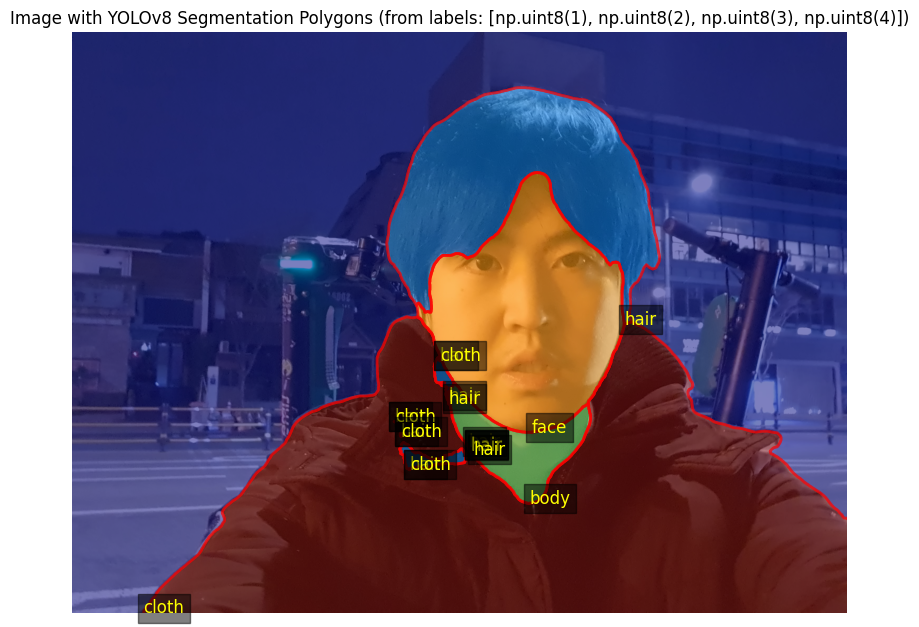

In [52]:
def mask_to_yolo_segmentation(mask, image_width, image_height, class_map):
    """
    현재의 정수형 레이블 세그먼트를 YOLOv8 세그먼트 형식으로 변환.

    Args:
        mask (np.array): (정수 레이블) 현재 세그먼트 마스크.
        image_width (int): 원본 이미지의 너비
        image_height (int): 원본 이미지의 높이
        class_map (dict): 현재 마스크 레이블과 YOLO 클래스 ID 간의 매핑

    Returns:
        list: 객체당 하나씩, YOLOv8 형식의 세그먼트 문자열 리스트
    """
    yolo_labels = []
    unique_labels = np.unique(mask)

    for label_value in unique_labels:
        if label_value == 0: continue # 배경은 스킵.

        # Get YOLO class ID from the map
        yolo_class_id = class_map.get(label_value)
        if yolo_class_id is None:
            print(f"Warning: Mask label {label_value} not found in class_map. Skipping.")
            continue

        # Find contours for the current label
        # 'mask == label_value' creates a binary mask for the current object
        contours = measure.find_contours(mask == label_value, 0.5) # 0.5 is the isolevel

        for contour in contours:
            # YOLOv8 expects x, y pairs, so flatten the contour and normalize
            # skimage contours are (row, col) i.e. (y, x)
            contour_normalized = []
            for y, x in contour:
                # Normalize coordinates to [0, 1]
                x_norm = x / image_width
                y_norm = y / image_height
                contour_normalized.extend([x_norm, y_norm])

            # Join coordinates with spaces and prefix with class_id
            if len(contour_normalized) > 0:
                yolo_line = f"{yolo_class_id} {' '.join(map(str, contour_normalized))}"
                yolo_labels.append(yolo_line)
    return yolo_labels

# --- Determine class mapping --- (This is crucial and depends on your specific labels)
# For demonstration, let's find unique non-zero labels in the current sample and map them
unique_segmentation_labels = [lbl for lbl in np.unique(segmentation_mask) if lbl != 0]
if not unique_segmentation_labels:
    print("No non-background labels found in the segmentation mask for this sample. Skipping label generation.")
    yolo_segmentation_labels = []
else:
    print(f"Unique non-background segmentation labels in this sample: {unique_segmentation_labels}")
    # Create a simple 0-indexed mapping for these labels
    # In a real scenario, you would have a fixed class_names list and a consistent mapping
    # For instance: class_names = ['background', 'face_part1', 'face_part2', ...]
    # Here, we'll just map the found unique labels directly to 0, 1, 2...
    segmentation_label_to_yolo_class_id = {1: 'hair',  2: 'body',  3: 'face',  4: 'cloth', 5: 'etc'}
    print(f"Segmentation label to YOLO class ID map: {segmentation_label_to_yolo_class_id}")

    # Convert mask to YOLO format
    yolo_segmentation_labels = mask_to_yolo_segmentation(segmentation_mask, img_width, img_height, segmentation_label_to_yolo_class_id)

    print("\nYOLOv8 Segmentation Labels for this sample (.txt file content):")
    for line in yolo_segmentation_labels:
        print(line)

# Visualizing the contours (optional, for verification)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.imshow(segmentation_mask, cmap='jet', alpha=0.5) # Overlay mask with transparency

for yolo_line in yolo_segmentation_labels:
    parts = yolo_line.split()
    class_id = parts[0]
    coords = list(map(float, parts[1:]))
    xs = [coords[i] * img_width for i in range(0, len(coords), 2)]
    ys = [coords[i+1] * img_height for i in range(0, len(coords), 2)]
    plt.plot(xs, ys, linewidth=2, color='red', alpha=0.7) # Draw polygons
    plt.text(xs[0], ys[0], str(class_id), color='yellow', fontsize=12, bbox=dict(facecolor='black', alpha=0.5))

plt.title(f"Image with YOLOv8 Segmentation Polygons (from labels: {unique_segmentation_labels})")
plt.axis('off')
plt.show()

In [53]:
DATASET_ROOT = '/workspace/user3/yolov8_dataset'

SUBDIRECTORIES = [
    'images/train',
    'images/val',
    'labels/train',
    'labels/val']

for subdir in SUBDIRECTORIES:
    path = os.path.join(DATASET_ROOT, subdir)
    os.makedirs(path, exist_ok=True)

In [54]:
import yaml

class_id = {1: 'hair',  2: 'body',  3: 'face',  4: 'cloth', 5: 'etc'}
class_names = ['hair',  'body',  'face',  'cloth', 'etc']

# data.yaml 파일 내용 생성
data_yaml_content = {
    'path': DATASET_ROOT, # 데이터셋 루트 경로
    'train': 'images/train',  # 학습 이미지 상대 경로
    'val': 'images/val',    # 검증 이미지 상대 경로
    'nc': len(class_names), # 클래스 수
    'names': class_names    # 클래스 이름 목록
}

# data.yaml 파일 저장 경로
data_yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')

# data.yaml 파일 작성
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"data.yaml 파일이 '{data_yaml_path}'에 성공적으로 생성되었습니다.")
print("생성된 data.yaml 내용:")
with open(data_yaml_path, 'r') as f:
    print(f.read())

data.yaml 파일이 '/workspace/user3/yolov8_dataset/data.yaml'에 성공적으로 생성되었습니다.
생성된 data.yaml 내용:
path: /workspace/user3/yolov8_dataset
train: images/train
val: images/val
nc: 5
names:
- hair
- body
- face
- cloth
- etc



In [55]:
full_dataset_iterator = combined_data_iterator()

def process_and_save_dataset(iterator, dataset_root, class_mapping):
    """
    Combined_data_iterator에서 데이터를 가져와 YOLOv8 형식으로 저장.
    이미지는 images/train/ 또는 images/val/ 에, 라벨은 labels/train/ 또는 labels/val/ 에 저장.
    """
    processed_count = 0
    skipped_count = 0

    for sample_entry in iterator:
        try:
            filename = sample_entry['filename']
            data_type = sample_entry['data_type'] # 'train' or 'val'
            original_img_path = sample_entry['img_path']
            segmentation_mask = sample_entry['segmentation_mask']

            # --- 1. 이미지 저장 ---
            img = Image.open(original_img_path).convert('RGB')
            img = ImageOps.exif_transpose(img)
            img_width, img_height = img.size

            # 저장 경로 설정
            img_output_dir = os.path.join(dataset_root, 'images', data_type)
            img_output_path = os.path.join(img_output_dir, filename)
            
            # 파일 이름에서 확장자 제거 (label 파일과 맞추기 위함)
            base_filename = os.path.splitext(filename)[0]
            
            # 이미지 파일 저장
            os.makedirs(img_output_dir, exist_ok=True)
            img.save(img_output_path)

            # --- 2. YOLOv8 라벨 생성 및 저장 ---
            # segmentation_mask와 class_mapping을 사용하여 YOLOv8 라벨 생성
            yolo_segmentation_labels = mask_to_yolo_segmentation(
                segmentation_mask, img_width, img_height, class_mapping
            )

            # 라벨 저장 경로 설정
            label_output_dir = os.path.join(dataset_root, 'labels', data_type)
            label_output_path = os.path.join(label_output_dir, f'{base_filename}.txt')
            
            os.makedirs(label_output_dir, exist_ok=True)

            if yolo_segmentation_labels:
                with open(label_output_path, 'w') as f:
                    for line in yolo_segmentation_labels:
                        f.write(line + '\n')
                processed_count += 1
            else:
                # 라벨이 없는 이미지도 저장할 수 있지만, YOLO는 라벨 없는 이미지는 무시함.
                # 여기서는 라벨이 없는 경우 파일을 만들지 않음. 필요에 따라 조정 필요.
                print(f"Warning: No YOLO segmentation labels generated for {filename}. Skipping label file creation.")
                skipped_count += 1

        except Exception as e:
            print(f"Error processing {sample_entry.get('filename', 'Unknown file')}: {e}")
            skipped_count += 1

    print(f"\nDataset processing complete. Processed {processed_count} samples, skipped {skipped_count} samples.")

# 데이터셋 처리 및 저장 시작
print("Starting dataset preparation for YOLOv8 training...")
process_and_save_dataset(full_dataset_iterator, DATASET_ROOT, class_id)
print("Dataset preparation finished.")

data_yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    print(f"\nContent of {data_yaml_path}:\n{f.read()}")

Starting dataset preparation for YOLOv8 training...
Loaded JSON for anger (train) from /workspace/데이터셋/label/train/train_anger.json
Loaded NPZ for anger (train) from /workspace/데이터셋/segmentation/train/train_anger.npz


Loaded JSON for happy (train) from /workspace/데이터셋/label/train/train_happy.json
Loaded NPZ for happy (train) from /workspace/데이터셋/segmentation/train/train_happy.npz
Loaded JSON for sadness (train) from /workspace/데이터셋/label/train/train_sadness.json
Loaded NPZ for sadness (train) from /workspace/데이터셋/segmentation/train/train_sadness.npz
Loaded JSON for panic (train) from /workspace/데이터셋/label/train/train_panic.json
Loaded NPZ for panic (train) from /workspace/데이터셋/segmentation/train/train_panic.npz
Loaded JSON for anger (val) from /workspace/데이터셋/label/val/val_anger.json
Loaded NPZ for anger (val) from /workspace/데이터셋/segmentation/val/val_anger.npz
Loaded JSON for happy (val) from /workspace/데이터셋/label/val/val_happy.json
Loaded NPZ for happy (val) from /workspace/데이터셋/segmentation/val/val_happy.npz
Loaded JSON for sadness (val) from /workspace/데이터셋/label/val/val_sadness.json
Loaded NPZ for sadness (val) from /workspace/데이터셋/segmentation/val/val_sadness.npz
Loaded JSON for panic (val) fr